# 02 - MLP (Multi-Layer Perceptron)

We're moving from bigrams to MLPs.
The bigram model was cool but dumb. It only looked one character back. 
The MLP fixes this. Theres a context window (ex. 3 characters) and it actually has something to work with. 
It learns embeddings for each character, passes them through a hidden layer, and outputs probabilities for what comes next.


In [78]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import pandas as pd

In [79]:
df = pd.read_parquet('data/0000.parquet')
comments = df['Comment'].dropna().tolist()
comments = [c.lower() for c in comments]

text = ''.join(comments)
chars = sorted(list(set(text)))
vocab_size = len(chars)

len(comments)

25430

In [80]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['|'] = 0
itos = {i:s for s,i in stoi.items()}    

In [81]:
random.seed(42)
random.shuffle(comments)

n1 = int(0.8 * len(comments))
n2 = int(0.9 * len(comments))

train = comments[:n1]
val = comments[n1:n2]
test = comments[n2:]

print(len(train))
print(len(val))
print(len(test))


20344
2543
2543


In [82]:
# Building the dataset
block_size = 3
def build_dataset(comments):
    X, Y = [], []
    for comment in comments: 
        context = [0] * block_size
        for ch in comment: 
            ix =stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
        X.append(context)
        Y.append(0)
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

In [83]:
Xtr, Ytr   = build_dataset(train)
Xval, Yval = build_dataset(val)
Xte, Yte   = build_dataset(test)

print(Xtr.shape, Ytr.shape)
print(Xval.shape, Yval.shape)
print(Xte.shape, Yte.shape)


torch.Size([3118732, 3]) torch.Size([3118732])
torch.Size([388886, 3]) torch.Size([388886])
torch.Size([395959, 3]) torch.Size([395959])


In [84]:
Xtr[:10]

tensor([[ 0,  0,  0],
        [ 0,  0, 47],
        [ 0, 47, 35],
        [47, 35, 32],
        [35, 32,  1],
        [32,  1, 28],
        [ 1, 28, 47],
        [28, 47, 47],
        [47, 47, 28],
        [47, 28, 30]])

In [85]:
Xtr.shape[0]

3118732

### Embedding : 

neural networks cannot express characters as is.. they need to be coverted into numbers for the model to learn and nudge. We must create an embedding matrix which assigns a set of values (2 for now and then we ll increase) to feed into the model for each of the character. the model learns and changes these embeddings and contextualises each character

In [86]:
C = torch.randn(74,2)

In [87]:
C[Xtr].shape

torch.Size([3118732, 3, 2])

- 3118732 training examples, each with a context window of 3 characters, each character represented by 2 embedding values.

In [88]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

3 characters, each character represented by 2 embedding values. 100 neurons in the hidden layer. 

In [89]:
W2 = torch.randn((100,74))
b2 = torch.randn(74)

100 neurons in the hidden layer and 74 unique character outputs.

In [90]:
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

8322


##### 4 standard steps in every training loop 
1. Forward pass --> compute predictions
2. Loss --> measure how wrong we are
3. Backward pass --> compute gradients
4. Update --> nudge weights

In [91]:
for i in range(20000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]                          
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2                       
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None #zeroes on every backprop iteration
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.1 * p.grad # gradient descent
    
print(f"final loss: {loss.item():.4f}")

final loss: 2.3750


Cross Entropy fn does the following:
  - converts logits to probabilities via softmax
  - looks at probability of correct character, and takes negative log of it 

Low loss = model confident and correct 
High loss = model is confused

In [92]:
for i in range(20000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    
    # update
    ## this step is all about hyperparameter (alpha) tuning
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 2.5380


20000 steps used and hyperparameter tuning performed


In [93]:
# train loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f"train loss: {train_loss.item():.4f}")

# val loss
emb = C[Xval]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Yval)
print(f"val loss: {val_loss.item():.4f}")

train loss: 2.1972
val loss: 2.1971


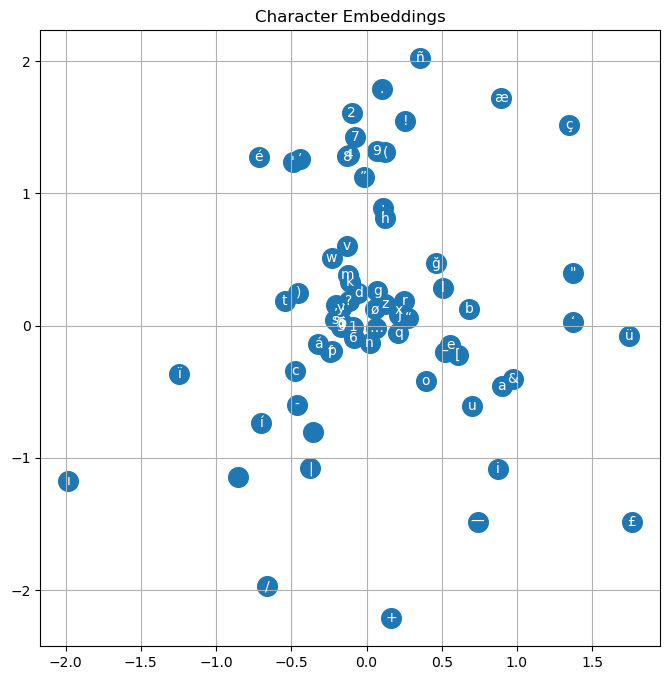

In [94]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(74):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid(True)
plt.title('Character Embeddings')
plt.show()

In [95]:
C  = torch.randn((74, 10))
W1 = torch.randn((30, 200))
b1 = torch.randn(200)
W2 = torch.randn((200, 74))
b2 = torch.randn(74)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

I increased the dimension of the embedding to 10 from 2 to experiment if that reduces the loss and in turn makes the model performs better


In [96]:
for i in range(20000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 2.3150


In [97]:
# train loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f"train loss: {train_loss.item():.4f}")

# val loss
emb = C[Xval]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Yval)
print(f"val loss: {val_loss.item():.4f}")

train loss: 2.1301
val loss: 2.1301


In [98]:
for i in range(200000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 1.4085


In [99]:
# train loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f"train loss: {train_loss.item():.4f}")

# val loss
emb = C[Xval]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Yval)
print(f"val loss: {val_loss.item():.4f}")

train loss: 1.6061
val loss: 1.6046


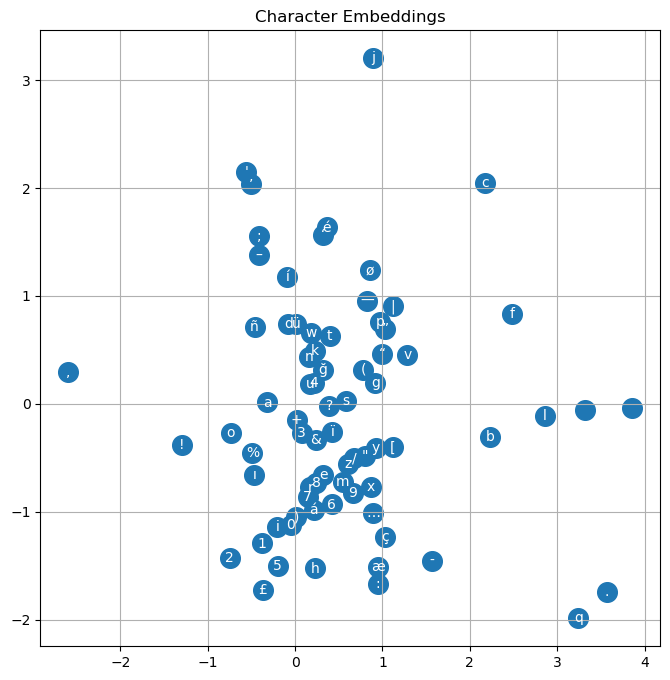

In [103]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(74):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid(True)
plt.title('Character Embeddings')
plt.show()

In [100]:
#g = torch.Generator().manual_seed(42)

for _ in range(5):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
    

wharabright dow carred inting that murity the othe survivere.|
savinut. blocked his the eason wide a being goaorner they sim goal 017 18. cited to come cand haven a from, conces his from to and midfieo the mava cont it to king-back at mant ther defends offlay firing the end box and first can't han goal den a narting say 29 yet it not vareolast the|
ddle. the and toikes areade haves ove from the cornevenked, whost manan way, perball be to the leit 1-0|
look take. the ball is liko den gome righ-breakinge it that thance!|
jitall spision acgoalkea: tark. injuring for from a cul palandezpoots he how reft coal days they dow stand dign, buh shot the substinez in they plapeter changer, the behing a he putchinside.|


## Final Takeaways

The MLP is a proper step up from bigrams. Bigrams were cool but they were always going to be limited, one character of context is just not enough.
With the MLP we get a context window, embeddings, and a hidden layer. The model now actually has something to work with. The output has, "blocked", "corner", "midfield", "1-0" which are actual football language. Its not perfect but its clearly learning football commentary structure.
The loss went from 2.4 in bigrams to 2.10 here. Since train and val loss are very similar, I can see that the model is generalising well

The embedding visualization was the coolest part for me. Nobody told the model that vowels belong together, it just figured that out on its own during training.

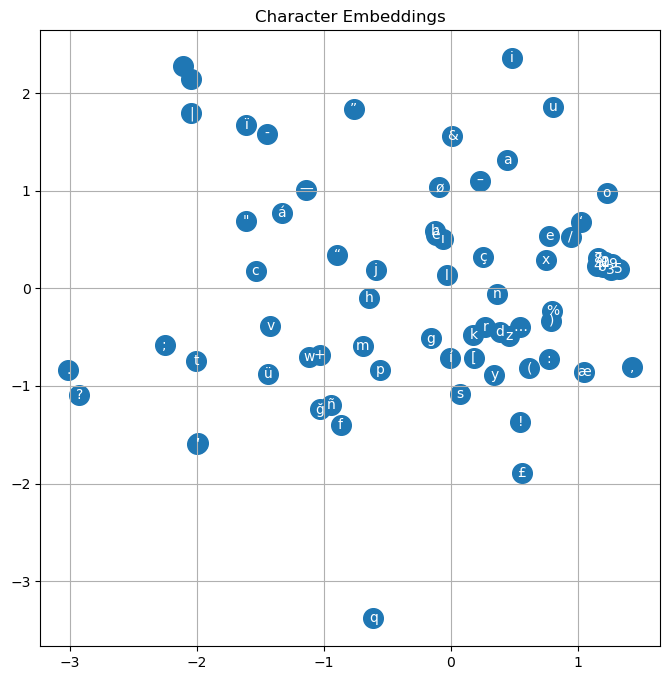

Numbers are clearly grouped together. Vowels are all over the place but they appear close to each other. The model is training well